# Semana 2: Matemáticas para Machine Learning

## DataQuest - Misión 2: Las Herramientas del Científico de Datos

---

### Objetivos de esta sesión

Al finalizar esta semana, serás capaz de:

1. Operar con vectores y matrices usando NumPy y entender su interpretación geométrica
2. Entender derivadas y gradientes como herramientas de optimización
3. Implementar gradiente descendente desde cero
4. Aplicar conceptos de probabilidad y el Teorema de Bayes
5. Conectar las matemáticas con los algoritmos de ML que veremos en el curso

---

## ¿Por qué matemáticas?

En la Semana 1 entrenamos un modelo de ML en pocas líneas de código. Parecía magia. Pero detrás de esas líneas hay matemáticas que hacen que todo funcione.

```
   Lo que VES:                         Lo que PASA por dentro:
   ═══════════                         ═════════════════════════
                                       
   modelo.fit(X, y)     ───▶   Álgebra Lineal: X · w = ŷ
                                       Cálculo: ∇L = ∂L/∂w
                                       Optimización: w = w - α∇L
                                       Probabilidad: P(y|X) = ?

   modelo.predict(X_new) ──▶   Multiplicación de matrices
                                       Función sigmoide
                                       Umbral de decisión
```

No necesitas ser un matemático experto, pero entender estos fundamentos te permitirá:

- **Diagnosticar** por qué un modelo no funciona bien
- **Elegir** el algoritmo correcto para cada problema
- **Ajustar** hiperparámetros con criterio, no por suerte
- **Entender** papers y documentación avanzada

### Las tres ramas que necesitamos

```
              MATEMÁTICAS PARA ML
                       │
        ┌──────────────┼──────────────┐
        │              │              │
        ▼              ▼              ▼
  ┌─────────┐   ┌─────────┐    ┌─────────────┐
  │ ÁLGEBRA │   │ CÁLCULO │    │PROBABILIDAD │
  │ LINEAL  │   │   Y     │    │     Y       │
  │         │   │ OPTIM.  │    │ESTADÍSTICA  │
  └─────────┘   └─────────┘    └─────────────┘
       │              │              │
  Representar     Encontrar el   Manejar la
  y transformar   mejor modelo   incertidumbre
  datos           posible        en predicciones
```

---

## 1. Álgebra Lineal Esencial

### 1.1 Vectores: Los bloques de construcción

Un **vector** es simplemente una lista ordenada de números. En ML, cada muestra de datos es un vector.

```
Una casa:                         Un vector:

  Tamaño: 120 m²                   ┌      ┐
  Habitaciones: 3                  │ 120  │
  Baños: 2                         │  3   │  = x
  Antigüedad: 10 años              │  2   │
                                   │  10  │
                                   └      ┘

  4 características = vector de 4 dimensiones
```

**En ML:**
- Cada **feature** es una dimensión
- Cada **muestra** es un vector en ese espacio
- Un dataset con 100 muestras y 4 features = 100 vectores de 4 dimensiones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# ============================================================
# VECTORES CON NUMPY
# ============================================================

# Crear vectores
v1 = np.array([3, 4])         # Vector 2D
v2 = np.array([1, 5])
casa = np.array([120, 3, 2, 10])  # Vector 4D (una muestra)

print("VECTORES CON NUMPY")
print("=" * 50)
print(f"v1 = {v1}")
print(f"v2 = {v2}")
print(f"casa = {casa}")
print(f"\nDimensiones de v1: {v1.shape}")
print(f"Dimensiones de casa: {casa.shape}")

VECTORES CON NUMPY
v1 = [3 4]
v2 = [1 5]
casa = [120   3   2  10]

Dimensiones de v1: (2,)
Dimensiones de casa: (4,)


### 1.2 Operaciones con vectores

In [2]:
# ============================================================
# OPERACIONES VECTORIALES
# ============================================================

v1 = np.array([3, 4])
v2 = np.array([1, 5])

# Suma
suma = v1 + v2
print("OPERACIONES CON VECTORES")
print("=" * 50)
print(f"v1 + v2 = {v1} + {v2} = {suma}")

# Resta
resta = v1 - v2
print(f"v1 - v2 = {v1} - {v2} = {resta}")

# Multiplicaci\u00f3n por escalar
escalado = 2 * v1
print(f"2 * v1 = 2 * {v1} = {escalado}")

# Producto punto (dot product) - MUY IMPORTANTE en ML
dot = np.dot(v1, v2)
print(f"\nv1 \u00b7 v2 = ({v1[0]}*{v2[0]}) + ({v1[1]}*{v2[1]}) = {dot}")
print(f"np.dot(v1, v2) = {dot}")

# Norma (magnitud/longitud del vector)
norma_v1 = np.linalg.norm(v1)
print(f"\n||v1|| = \u221a({v1[0]}\u00b2 + {v1[1]}\u00b2) = \u221a({v1[0]**2} + {v1[1]**2}) = {norma_v1:.2f}")
print(f"np.linalg.norm(v1) = {norma_v1:.2f}")

OPERACIONES CON VECTORES
v1 + v2 = [3 4] + [1 5] = [4 9]
v1 - v2 = [3 4] - [1 5] = [ 2 -1]
2 * v1 = 2 * [3 4] = [6 8]

v1 · v2 = (3*1) + (4*5) = 23
np.dot(v1, v2) = 23

||v1|| = √(3² + 4²) = √(9 + 16) = 5.00
np.linalg.norm(v1) = 5.00


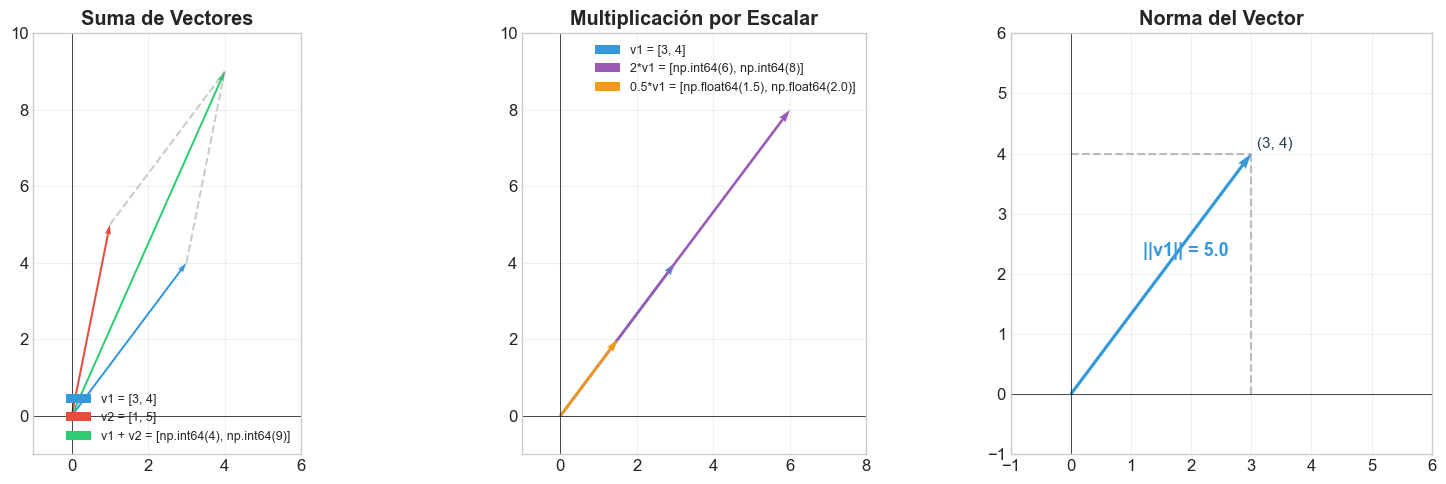


El PRODUCTO PUNTO es fundamental en ML:
  - Regresión lineal: y = w · x + b  (producto punto entre pesos y features)
  - SVM: separa clases con hiperplanos definidos por productos punto
  - Redes neuronales: cada neurona calcula un producto punto


In [3]:
# VISUALIZACION: Operaciones con vectores en 2D

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Grafica 1: Suma de vectores ---
ax = axes[0]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='#3498db', linewidth=2, label='v1 = [3, 4]')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='#e74c3c', linewidth=2, label='v2 = [1, 5]')
ax.quiver(0, 0, suma[0], suma[1], angles='xy', scale_units='xy', scale=1,
          color='#2ecc71', linewidth=2.5, label=f'v1 + v2 = {list(suma)}')
# Lineas punteadas (paralelogramo)
ax.plot([v1[0], suma[0]], [v1[1], suma[1]], '--', color='gray', alpha=0.4)
ax.plot([v2[0], suma[0]], [v2[1], suma[1]], '--', color='gray', alpha=0.4)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_title('Suma de Vectores', fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# --- Grafica 2: Multiplicacion por escalar ---
ax = axes[1]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='#3498db', linewidth=2, label='v1 = [3, 4]')
ax.quiver(0, 0, escalado[0], escalado[1], angles='xy', scale_units='xy', scale=1,
          color='#9b59b6', linewidth=2.5, label=f'2*v1 = {list(escalado)}')
medio = 0.5 * v1
ax.quiver(0, 0, medio[0], medio[1], angles='xy', scale_units='xy', scale=1,
          color='#f39c12', linewidth=2, label=f'0.5*v1 = {list(medio)}')
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_title('Multiplicaci\u00f3n por Escalar', fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# --- Grafica 3: Norma (magnitud) ---
ax = axes[2]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='#3498db', linewidth=2.5)
# Lineas punteadas al eje
ax.plot([v1[0], v1[0]], [0, v1[1]], '--', color='gray', alpha=0.5)
ax.plot([0, v1[0]], [v1[1], v1[1]], '--', color='gray', alpha=0.5)
ax.annotate(f'||v1|| = {norma_v1:.1f}', xy=(v1[0]/2 - 0.3, v1[1]/2 + 0.3),
            fontsize=13, color='#3498db', fontweight='bold')
ax.annotate(f'({v1[0]}, {v1[1]})', xy=(v1[0]+0.1, v1[1]+0.1),
            fontsize=11, color='#2c3e50')
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'Norma del Vector', fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('vectores_operaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEl PRODUCTO PUNTO es fundamental en ML:")
print("  - Regresi\u00f3n lineal: y = w \u00b7 x + b  (producto punto entre pesos y features)")
print("  - SVM: separa clases con hiperplanos definidos por productos punto")
print("  - Redes neuronales: cada neurona calcula un producto punto")

### 1.3 Matrices: Tablas de datos

Una **matriz** es una tabla rectangular de números. En ML, el dataset completo es una matriz.

```
Dataset de casas:                    Matriz X:

  m²   hab  baños  antig             ┌                  ┐
  120   3    2     10                │ 120   3   2   10 │
   85   2    1     20    ──▶        │  85   2   1   20  │  = X (3x4)
  200   4    3      5                │ 200   4   3    5 │
                                     └                  ┘

  3 muestras x 4 features = Matriz de 3 filas x 4 columnas
```

**Notación:** X tiene forma (n, m) donde n = muestras, m = features

In [4]:
# ============================================================
# MATRICES CON NUMPY
# ============================================================

# Crear matrices
X = np.array([
    [120, 3, 2, 10],
    [ 85, 2, 1, 20],
    [200, 4, 3,  5]
])

print("MATRICES CON NUMPY")
print("=" * 50)
print(f"Matriz X:")
print(X)
print(f"\nForma (shape): {X.shape}  \u2192 {X.shape[0]} filas (muestras) x {X.shape[1]} columnas (features)")
print(f"\nAcceder a una fila (muestra 0):    X[0]  = {X[0]}")
print(f"Acceder a una columna (feature 1): X[:,1] = {X[:,1]}")
print(f"Acceder a un elemento:             X[1,2] = {X[1,2]}")

MATRICES CON NUMPY
Matriz X:
[[120   3   2  10]
 [ 85   2   1  20]
 [200   4   3   5]]

Forma (shape): (3, 4)  → 3 filas (muestras) x 4 columnas (features)

Acceder a una fila (muestra 0):    X[0]  = [120   3   2  10]
Acceder a una columna (feature 1): X[:,1] = [3 2 4]
Acceder a un elemento:             X[1,2] = 1


In [5]:
# ============================================================
# OPERACIONES MATRICIALES
# ============================================================

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("OPERACIONES MATRICIALES")
print("=" * 50)

# Transpuesta
print(f"A =\n{A}")
print(f"B =\n{B}")
print(f"\nTranspuesta A^T =\n{A.T}")
print("   (filas se vuelven columnas y viceversa)")

# Multiplicacion de matrices
C = A @ B   # Equivalente a np.dot(A, B)
print(f"\nA @ B =\n{C}")
print(f"   C[0,0] = ({A[0,0]}*{B[0,0]}) + ({A[0,1]}*{B[1,0]}) = {C[0,0]}")

# Inversa
A_inv = np.linalg.inv(A)
print(f"\nInversa A\u207b\u00b9 =\n{A_inv.round(2)}")
print(f"\nVerificaci\u00f3n A @ A\u207b\u00b9 = I:\n{(A @ A_inv).round(2)}")

OPERACIONES MATRICIALES
A =
[[1 2]
 [3 4]]
B =
[[5 6]
 [7 8]]

Transpuesta A^T =
[[1 3]
 [2 4]]
   (filas se vuelven columnas y viceversa)

A @ B =
[[19 22]
 [43 50]]
   C[0,0] = (1*5) + (2*7) = 19

Inversa A⁻¹ =
[[-2.   1. ]
 [ 1.5 -0.5]]

Verificación A @ A⁻¹ = I:
[[1. 0.]
 [0. 1.]]


Algoritmo para calcular la inverza. Factorizacion LU

1. Factorizar A = LU  (una sola vez)
2. Para i = 1 hasta n:
    - Forward:  L y = eᵢ
    - Backward: U x = y
    - Columna i de A⁻¹ ← x
3. Ensamblar A⁻¹

### 1.4 Multiplicación de matrices en ML

La multiplicación de matrices es la operación más importante. Permite hacer predicciones para TODAS las muestras a la vez.

```
REGRESIÓN LINEAL: ŷ = X · w

  ┌           ┐   ┌     ┐     ┌       ┐
  │ 120  3  2 │   │ 100 │     │ 12600 │
  │  85  2  1 │ @ │  50 │  =  │  8750 │
  │ 200  4  3 │   │  25 │     │ 20275 │
  └           ┘   └     ┘     └       ┘
     X (3x3)     w (3x1)    ŷ (3x1)
   (datos)     (pesos)    (predicciones)

  Cada predicción = producto punto de una fila de X con w
  Casa 1: 120*100 + 3*50 + 2*25 = 12,600
  Casa 2:  85*100 + 2*50 + 1*25 =  8,750
```

In [6]:
# Ejemplo: Prediccion con multiplicacion de matrices

# Datos de 3 casas (3 features: m2, habitaciones, ba\u00f1os)
X = np.array([
    [120, 3, 2],
    [ 85, 2, 1],
    [200, 4, 3]
])

# Pesos aprendidos por el modelo (precio por m2, por habitacion, por ba\u00f1o)
w = np.array([15000, 200000, 150000])

# Prediccion para TODAS las casas a la vez
predicciones = X @ w

print("PREDICCI\u00d3N CON MATRICES")
print("=" * 50)
print(f"Datos (X):\n{X}")
print(f"\nPesos (w): {w}")
print(f"\nPredicciones (X @ w):")
for i, pred in enumerate(predicciones):
    print(f"  Casa {i+1}: ${pred:,.0f} pesos")

print("\nEsto es EXACTAMENTE lo que hace la regresi\u00f3n lineal.")
print("Solo necesita encontrar los mejores pesos w.")

PREDICCIÓN CON MATRICES
Datos (X):
[[120   3   2]
 [ 85   2   1]
 [200   4   3]]

Pesos (w): [ 15000 200000 150000]

Predicciones (X @ w):
  Casa 1: $2,700,000 pesos
  Casa 2: $1,825,000 pesos
  Casa 3: $4,250,000 pesos

Esto es EXACTAMENTE lo que hace la regresión lineal.
Solo necesita encontrar los mejores pesos w.


### 1.5 Eigenvalores y Eigenvectores (intuición para PCA)

Los **eigenvectores** son las direcciones principales de variación de los datos. Los **eigenvalores** indican cuánta variación hay en cada dirección.

```
INTUICIÓN:

   Imagina una nube de puntos (datos):

              *  *
           * * * * *
         * * * * * * *        Eigenvector 1 (mayor variacion)
       * * * * * * * * *    ───────────▶
         * * * * * * *        Eigenvector 2 (menor variacion)
           * * * * *              │
              *  *                ▼

   El eigenvector 1 captura la MAYOR variacion
   El eigenvector 2 captura la MENOR variacion

   PCA usa esto para reducir dimensiones:
   Si el eigenvalor 2 es muy pequeño, esa direccion importa poco
   - Podemos proyectar los datos solo en la direccion 1
   - De 2D a 1D sin perder mucha informacion
```

Lo veremos a fondo en la **Semana 12** cuando estudiemos PCA.

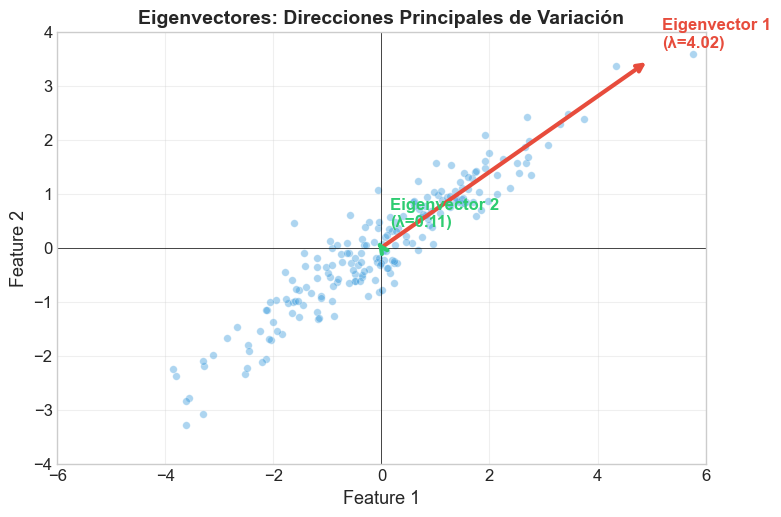


Eigenvalores: [4.02 0.11]
Varianza explicada por eigenvector 1: 97.4%
Varianza explicada por eigenvector 2: 2.6%

Si proyectamos en eigenvector 1 solamente,
conservamos el 97.4% de la información.


In [7]:
# VISUALIZACION: Eigenvectores como direcciones principales

np.random.seed(42)

# Datos con correlacion (nube alargada)
media = [0, 0]
covarianza = [[3, 2], [2, 1.5]]
datos = np.random.multivariate_normal(media, covarianza, 200)

# Calcular eigenvectores de la matriz de covarianza
cov_matrix = np.cov(datos.T)
eigenvalores, eigenvectores = np.linalg.eig(cov_matrix)

# Ordenar por eigenvalor (mayor primero)
idx = eigenvalores.argsort()[::-1]
eigenvalores = eigenvalores[idx]
eigenvectores = eigenvectores[:, idx]

fig, ax = plt.subplots(figsize=(8, 8))

# Graficar puntos
ax.scatter(datos[:, 0], datos[:, 1], alpha=0.4, s=30, c='#3498db', edgecolors='white', linewidth=0.5)

# Graficar eigenvectores (escalados por eigenvalor para visualizar)
colores_eig = ['#e74c3c', '#2ecc71']
for i in range(2):
    escala = eigenvalores[i] * 1.5
    ax.annotate('', xy=eigenvectores[:, i] * escala, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colores_eig[i], lw=3))
    ax.annotate(f'Eigenvector {i+1}\n(\u03bb={eigenvalores[i]:.2f})',
                xy=eigenvectores[:, i] * escala,
                fontsize=12, color=colores_eig[i], fontweight='bold',
                xytext=(10, 10), textcoords='offset points')

ax.set_xlim(-6, 6)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Feature 1', fontsize=13)
ax.set_ylabel('Feature 2', fontsize=13)
ax.set_title('Eigenvectores: Direcciones Principales de Variaci\u00f3n', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('eigenvectores.png', dpi=150, bbox_inches='tight')
plt.show()

varianza_total = eigenvalores.sum()
print(f"\nEigenvalores: {eigenvalores.round(2)}")
print(f"Varianza explicada por eigenvector 1: {eigenvalores[0]/varianza_total:.1%}")
print(f"Varianza explicada por eigenvector 2: {eigenvalores[1]/varianza_total:.1%}")
print(f"\nSi proyectamos en eigenvector 1 solamente,")
print(f"conservamos el {eigenvalores[0]/varianza_total:.1%} de la informaci\u00f3n.")

---

## 2. Cálculo para Optimización

### 2.1 Derivadas: La brujula del aprendizaje

La **derivada** nos dice cómo cambia una función cuando movemos su entrada un poquito. En ML, nos dice en qué dirección ajustar los parámetros para mejorar el modelo.

```
DERIVADA = Pendiente de la función en un punto

    f(x)
      │           .
      │         .   .
      │       .       .
      │     .     /     .     derivada > 0: subiendo
      │   .     /         .   derivada = 0: mínimo o máximo
      │ .    ← pendiente    .  derivada < 0: bajando
      │.                     .
      └─────────────────────▶ x

   Si la derivada es POSITIVA  → la función está subiendo  → mueve x a la IZQUIERDA
   Si la derivada es NEGATIVA  → la función está bajando  → mueve x a la DERECHA
   Si la derivada es CERO      → estás en un mínimo (o máximo)
```

### Derivadas comunes que veremos en ML

| Función | Derivada | Dónde aparece en ML |
|---------|----------|--------------------|
| x² | 2x | MSE (error cuadrático) |
| e^x | e^x | Función softmax |
| ln(x) | 1/x | Log-loss, MLE |
| 1/(1+e^(-x)) | σ(x)(1-σ(x)) | Regresión logística |

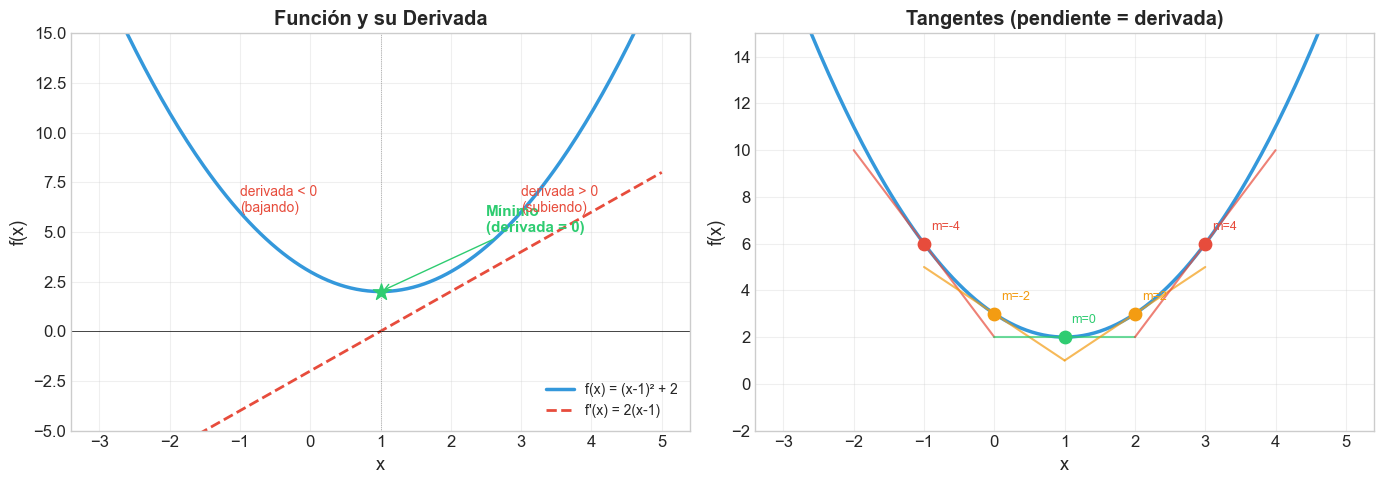

In [8]:
# VISUALIZACION: Derivada como pendiente en un punto

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-3, 5, 200)

# --- Grafica 1: Funcion y su derivada ---
# f(x) = (x - 1)^2 + 2
f = (x - 1)**2 + 2
df = 2 * (x - 1)  # derivada

ax = axes[0]
ax.plot(x, f, color='#3498db', linewidth=2.5, label='f(x) = (x-1)\u00b2 + 2')
ax.plot(x, df, color='#e74c3c', linewidth=2, linestyle='--', label="f'(x) = 2(x-1)")
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=1, color='gray', linewidth=0.5, linestyle=':')

# Marcar el minimo
ax.scatter([1], [2], color='#2ecc71', s=150, zorder=5, marker='*')
ax.annotate('M\u00ednimo\n(derivada = 0)', xy=(1, 2), xytext=(2.5, 5),
            fontsize=11, color='#2ecc71', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2ecc71'))

# Anotaciones de pendiente
ax.annotate('derivada < 0\n(bajando)', xy=(-1, 6), fontsize=10, color='#e74c3c')
ax.annotate('derivada > 0\n(subiendo)', xy=(3, 6), fontsize=10, color='#e74c3c')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Funci\u00f3n y su Derivada', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-5, 15)
ax.grid(True, alpha=0.3)

# --- Grafica 2: Tangentes en distintos puntos ---
ax = axes[1]
ax.plot(x, f, color='#3498db', linewidth=2.5, label='f(x) = (x-1)\u00b2 + 2')

puntos = [-1, 0, 1, 2, 3]
colores_t = ['#e74c3c', '#f39c12', '#2ecc71', '#f39c12', '#e74c3c']
for px, color in zip(puntos, colores_t):
    py = (px - 1)**2 + 2
    slope = 2 * (px - 1)
    # Linea tangente
    x_tang = np.linspace(px - 1, px + 1, 50)
    y_tang = slope * (x_tang - px) + py
    ax.plot(x_tang, y_tang, color=color, linewidth=1.5, alpha=0.7)
    ax.scatter([px], [py], color=color, s=80, zorder=5)
    ax.annotate(f'm={slope:.0f}', xy=(px, py), xytext=(5, 10),
                textcoords='offset points', fontsize=9, color=color)

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Tangentes (pendiente = derivada)', fontweight='bold')
ax.set_ylim(-2, 15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('derivadas_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Gradientes: Derivadas en múltiples dimensiones

Cuando tenemos más de un parámetro (lo normal en ML), usamos el **gradiente**: un vector de derivadas parciales.

```
1 variable:     derivada  f'(x)       = un número
2+ variables:   gradiente ∇f(x,y)     = un VECTOR [∂f/∂x, ∂f/∂y]


Ejemplo: f(x,y) = x² + y²

  ∇f = [∂f/∂x, ∂f/∂y] = [2x, 2y]

  En el punto (3, 4):
  ∇f(3,4) = [6, 8]
  
  Esto significa:
  - Si mueves x un poquito, f cambia 6 veces más
  - Si mueves y un poquito, f cambia 8 veces más
  - El gradiente APUNTA hacia donde f crece más rápido
```

El gradiente siempre apunta en la dirección de **máximo crecimiento**. Para encontrar el mínimo, vamos en la dirección **contraria** al gradiente.

### 2.3 Función de costo/pérdida

La **función de costo** (o pérdida) mide qué tan mal le va al modelo. El objetivo de entrenar es **minimizarla**.

```
FUNCIÓN DE COSTO (LOSS)

   Costo
    │
    │───.
    │     ──.
    │        ─.
    │          ─.
    │            ──────.            ← Queremos llegar AQUÍ
    │                    ──.
    │                       ───.
    └─────────────────────────────▶
                 Iteraciones de entrenamiento
```

**Funciones de costo comunes:**

| Nombre | Fórmula | Uso |
|--------|---------|-----|
| MSE (Mean Squared Error) | (1/n) Σ(yᵢ - ŷᵢ)² | Regresión |
| MAE (Mean Absolute Error) | (1/n) Σ|yᵢ - ŷᵢ| | Regresión (robusta a outliers) |
| Log-Loss (Cross-Entropy) | -(1/n) Σ[y log(ŷ) + (1-y) log(1-ŷ)] | Clasificación |

### 2.4 Gradiente Descendente: Algoritmo bajando la montaña

El **gradiente descendente** es el algoritmo fundamental de optimización en ML. La idea es simple:

```
ANALOGÍA: Estás en una montaña con niebla.
Quieres bajar al valle (mínimo).
No ves nada, pero puedes SENTIR la pendiente bajo tus pies.

Estrategia:
1. Siente hacia dónde baja el terreno  →  Calcula el gradiente
2. Da un paso en esa dirección         →  Actualiza parámetros
3. Repite hasta llegar al fondo        →  Iterar hasta convergencia

FÓRMULA:

   w_nuevo = w_actual - α * ∇L(w)
                        │       │
                        │       └─ Gradiente (dirección de subida)
                        └─ Learning rate (tamaño del paso)

   El SIGNO MENOS hace que vayamos en dirección CONTRARIA al gradiente
   (queremos BAJAR, no subir)
```

In [9]:
# ============================================================
# GRADIENTE DESCENDENTE EN 1D
# ============================================================

# Funcion: f(x) = (x - 3)^2 + 5
# Derivada: f'(x) = 2(x - 3)
# Minimo en x = 3, f(3) = 5

def f(x):
    return (x - 3)**2 + 5

def df(x):
    return 2 * (x - 3)

# Parametros del gradiente descendente
x_actual = -2.0       # Punto inicial (lejos del minimo)
learning_rate = 0.1   # Tamano del paso
n_iteraciones = 30

# Almacenar historial
historial_x = [x_actual]
historial_f = [f(x_actual)]

print("GRADIENTE DESCENDENTE EN 1D")
print("=" * 60)
print(f"Función: f(x) = (x - 3)² + 5")
print(f"Mínimo real: x = 3, f(3) = 5")
print(f"\nPunto inicial: x = {x_actual}")
print(f"Learning rate: {learning_rate}")
deriv_header = "f'(x)"
print(f"\n{'Iter':>5} {'x':>10} {'f(x)':>10} {deriv_header:>10} {'paso':>10}")
print("-" * 50)

for i in range(n_iteraciones):
    gradiente = df(x_actual)
    paso = learning_rate * gradiente
    
    if i < 10 or i == n_iteraciones - 1:
        print(f"{i:>5} {x_actual:>10.4f} {f(x_actual):>10.4f} {gradiente:>10.4f} {paso:>10.4f}")
    elif i == 10:
        print(f"{'...':>5}")
    
    x_actual = x_actual - paso
    historial_x.append(x_actual)
    historial_f.append(f(x_actual))

print(f"\nResultado final: x = {x_actual:.6f}, f(x) = {f(x_actual):.6f}")
print(f"Error vs mínimo real: |{x_actual - 3:.6f}|")

GRADIENTE DESCENDENTE EN 1D
Función: f(x) = (x - 3)² + 5
Mínimo real: x = 3, f(3) = 5

Punto inicial: x = -2.0
Learning rate: 0.1

 Iter          x       f(x)      f'(x)       paso
--------------------------------------------------
    0    -2.0000    30.0000   -10.0000    -1.0000
    1    -1.0000    21.0000    -8.0000    -0.8000
    2    -0.2000    15.2400    -6.4000    -0.6400
    3     0.4400    11.5536    -5.1200    -0.5120
    4     0.9520     9.1943    -4.0960    -0.4096
    5     1.3616     7.6844    -3.2768    -0.3277
    6     1.6893     6.7180    -2.6214    -0.2621
    7     1.9514     6.0995    -2.0972    -0.2097
    8     2.1611     5.7037    -1.6777    -0.1678
    9     2.3289     5.4504    -1.3422    -0.1342
  ...
   29     2.9923     5.0001    -0.0155    -0.0015

Resultado final: x = 2.993810, f(x) = 5.000038
Error vs mínimo real: |-0.006190|


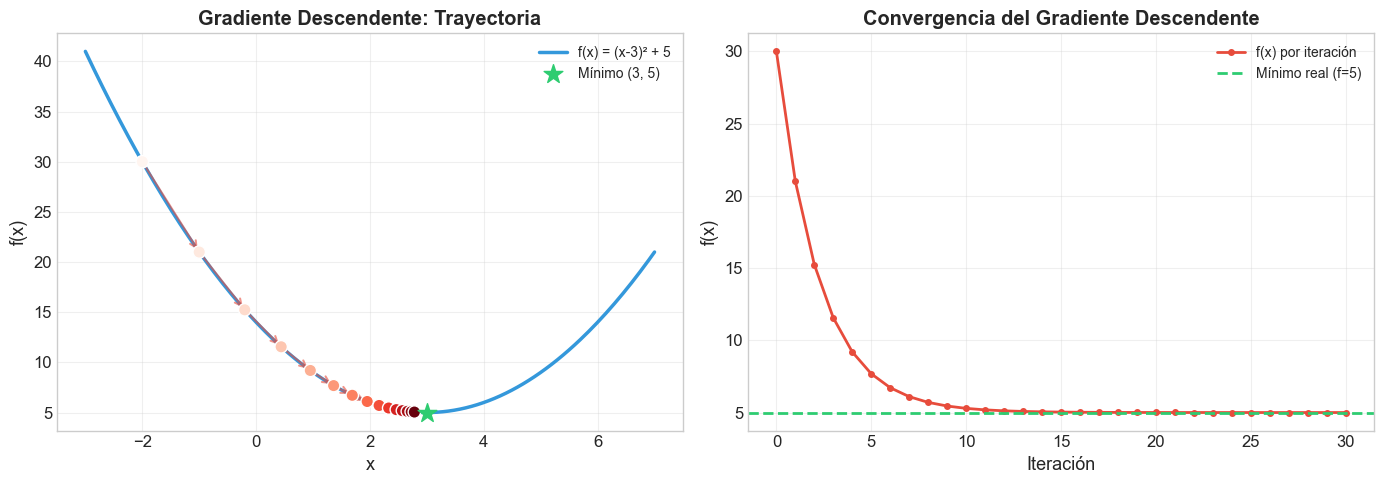

Observa cómo el algoritmo 'baja la montaña' paso a paso.
Los pasos son GRANDES al inicio (gradiente grande) y PEQUEÑOS cerca del mínimo.


In [10]:
# VISUALIZACION: Gradiente descendente en 1D

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_range = np.linspace(-3, 7, 200)

# --- Grafica 1: Trayectoria sobre la funcion ---
ax = axes[0]
ax.plot(x_range, f(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

# Puntos de la trayectoria
ax.scatter(historial_x[:15], historial_f[:15], c=range(min(15, len(historial_x))),
           cmap='Reds', s=80, zorder=5, edgecolors='white', linewidth=1)

# Flechas entre puntos
for i in range(min(8, len(historial_x)-1)):
    ax.annotate('', xy=(historial_x[i+1], historial_f[i+1]),
                xytext=(historial_x[i], historial_f[i]),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5, alpha=0.6))

# Marcar minimo
ax.scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo (3, 5)')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Gradiente Descendente: Trayectoria', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
ax = axes[1]
ax.plot(range(len(historial_f)), historial_f, 'o-', color='#e74c3c',
        linewidth=2, markersize=4, label='f(x) por iteraci\u00f3n')
ax.axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo real (f=5)')

ax.set_xlabel('Iteraci\u00f3n', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Convergencia del Gradiente Descendente', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradiente_descendente_1d.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observa c\u00f3mo el algoritmo 'baja la monta\u00f1a' paso a paso.")
print("Los pasos son GRANDES al inicio (gradiente grande) y PEQUE\u00d1OS cerca del m\u00ednimo.")

### 2.5 El Learning Rate: El parámetro más importante

El **learning rate** (α o lr) controla qué tan grande es cada paso:

```
LR MUY PEQUEÑO:           LR CORRECTO:            LR MUY GRANDE:

     .                        .                        .     
    . .                      . .                      . .    
   .   .                    .   .                    .   .   
  . .  .                   .  .  .                  .  .  .  
 . . . .                  . .  .  .                .        .
. . . . .                .  *minimo                       .  .
  . . . . . . . . .     Converge rápido!           NO CONVERGE
  Muy lento, se queda                             Salta sin control
```

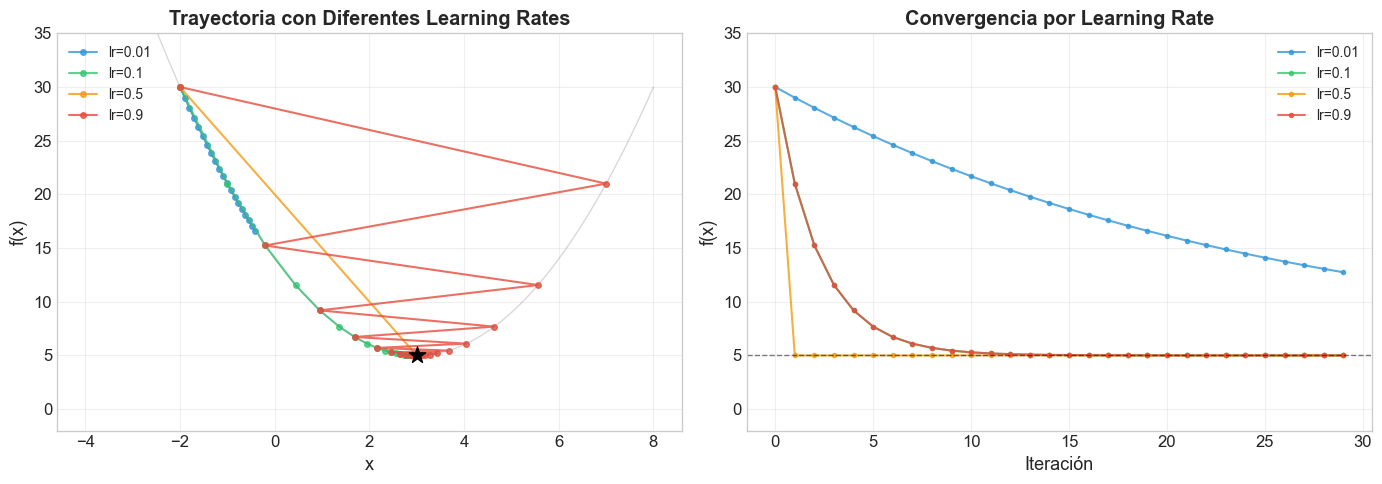

Observaciones:
  lr=0.01: Converge pero MUY lento (muchas iteraciones)
  lr=0.1:  Converge rápido y estable (buen balance)
  lr=0.5:  Converge rápido pero oscila un poco
  lr=0.9:  Oscila mucho, dificultad para converger


In [11]:
# VISUALIZACION: Efecto del learning rate

learning_rates = [0.01, 0.1, 0.5, 0.9]
colores_lr = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, color in zip(learning_rates, colores_lr):
    x_val = -2.0
    hist_x = [x_val]
    hist_f = [f(x_val)]
    
    for _ in range(40):
        x_val = x_val - lr * df(x_val)
        # Limitar para evitar explosion
        if abs(x_val) > 100:
            break
        hist_x.append(x_val)
        hist_f.append(f(x_val))
    
    # Grafica de trayectoria
    axes[0].plot(hist_x[:20], hist_f[:20], 'o-', color=color,
                linewidth=1.5, markersize=4, label=f'lr={lr}', alpha=0.8)
    
    # Grafica de convergencia
    axes[1].plot(range(len(hist_f[:30])), hist_f[:30], 'o-', color=color,
                linewidth=1.5, markersize=3, label=f'lr={lr}', alpha=0.8)

# Grafica 1
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f(x_range), color='gray', linewidth=1, alpha=0.3)
axes[0].scatter([3], [5], color='black', s=150, marker='*', zorder=10)
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria con Diferentes Learning Rates', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_ylim(-2, 35)
axes[0].grid(True, alpha=0.3)

# Grafica 2
axes[1].axhline(y=5, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Convergencia por Learning Rate', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(-2, 35)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rate_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observaciones:")
print("  lr=0.01: Converge pero MUY lento (muchas iteraciones)")
print("  lr=0.1:  Converge r\u00e1pido y estable (buen balance)")
print("  lr=0.5:  Converge r\u00e1pido pero oscila un poco")
print("  lr=0.9:  Oscila mucho, dificultad para converger")

### 2.6 Gradiente Descendente en 2D

Cuando tenemos 2 parámetros (por ejemplo, pendiente y ordenada al origen en regresión lineal), el gradiente descendente se mueve en un espacio 2D.

```
Vista superior (contornos de nivel):

        y
        │        
        │   ┌──────────┐
        │   │  ┌──────┐  │
        │   │  │  ┌──┐  │  │
    *──▶│───│──│──│* │  │  │   * = mínimo
        │   │  │  └──┘  │  │
        │   │  └──────┘  │   La trayectoria va
        │   └──────────┘   del borde al centro
        └───────────────▶ x
```

In [12]:
# ============================================================
# GRADIENTE DESCENDENTE EN 2D
# ============================================================

# Funcion: f(x, y) = x^2 + y^2 - 4x - 2y + 5
# Gradiente: [2x - 4, 2y - 2]
# Minimo en (2, 1), f(2,1) = 0

def f_2d(x, y):
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    return np.array([2*x - 4, 2*y - 2])

# Gradiente descendente
pos = np.array([-1.0, 4.0])  # Punto inicial
lr = 0.1
n_iter = 30

hist_pos = [pos.copy()]
hist_val = [f_2d(pos[0], pos[1])]

print("GRADIENTE DESCENDENTE EN 2D")
print("=" * 70)
print(f"Funci\u00f3n: f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5")
print(f"M\u00ednimo real: (2, 1), f(2,1) = 0")
print(f"Punto inicial: ({pos[0]}, {pos[1]})")
print(f"Learning rate: {lr}")
print(f"\n{'Iter':>5} {'x':>8} {'y':>8} {'f(x,y)':>10} {'|grad|':>10}")
print("-" * 50)

for i in range(n_iter):
    g = grad_2d(pos[0], pos[1])
    norma_g = np.linalg.norm(g)
    
    if i < 10 or i >= n_iter - 5:
        print(f"{i:>5} {pos[0]:>8.4f} {pos[1]:>8.4f} {f_2d(pos[0], pos[1]):>10.4f} {norma_g:>10.4f}")
    elif i == 10:
        print(f"{'...':>5}")
    
    pos = pos - lr * g
    hist_pos.append(pos.copy())
    hist_val.append(f_2d(pos[0], pos[1]))

print(f"\nResultado: ({pos[0]:.6f}, {pos[1]:.6f}), f = {f_2d(pos[0], pos[1]):.6f}")

GRADIENTE DESCENDENTE EN 2D
Función: f(x,y) = x² + y² - 4x - 2y + 5
Mínimo real: (2, 1), f(2,1) = 0
Punto inicial: (-1.0, 4.0)
Learning rate: 0.1

 Iter        x        y     f(x,y)     |grad|
--------------------------------------------------
    0  -1.0000   4.0000    18.0000     8.4853
    1  -0.4000   3.4000    11.5200     6.7882
    2   0.0800   2.9200     7.3728     5.4306
    3   0.4640   2.5360     4.7186     4.3445
    4   0.7712   2.2288     3.0199     3.4756
    5   1.0170   1.9830     1.9327     2.7805
    6   1.2136   1.7864     1.2370     2.2244
    7   1.3709   1.6291     0.7916     1.7795
    8   1.4967   1.5033     0.5067     1.4236
    9   1.5973   1.4027     0.3243     1.1389
  ...
   25   1.9887   1.0113     0.0003     0.0321
   26   1.9909   1.0091     0.0002     0.0256
   27   1.9927   1.0073     0.0001     0.0205
   28   1.9942   1.0058     0.0001     0.0164
   29   1.9954   1.0046     0.0000     0.0131

Resultado: (1.996286, 1.003714), f = 0.000028


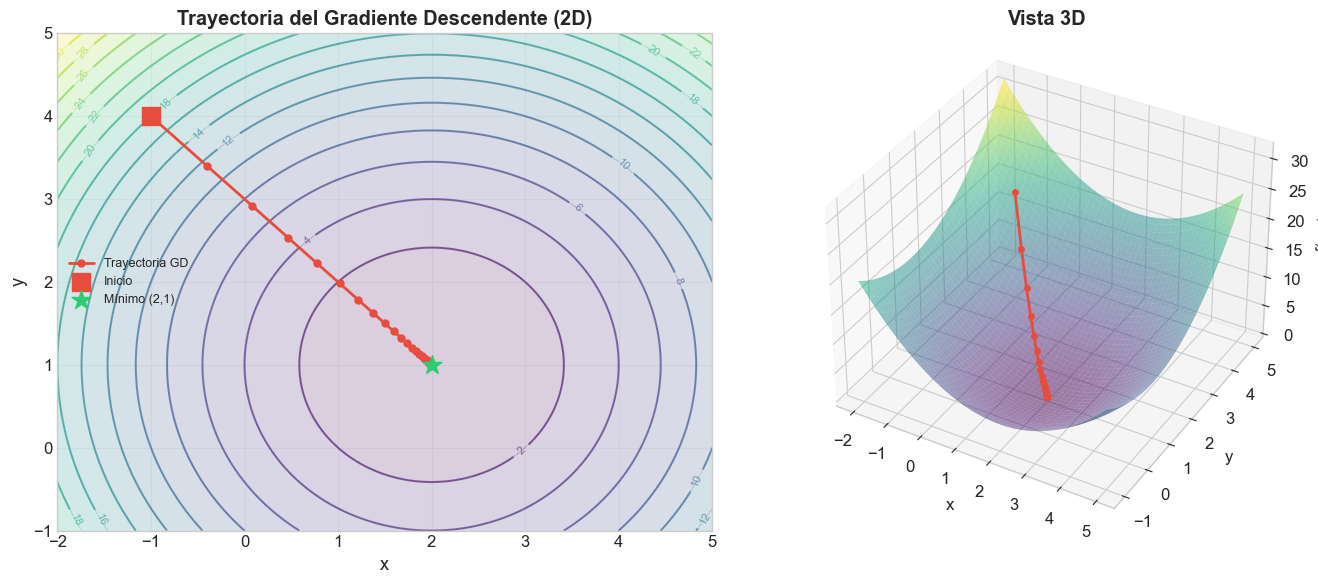

La trayectoria va directamente hacia el mínimo, como una pelota rodando cuesta abajo.


In [13]:
# VISUALIZACION: Gradiente descendente en 2D con contornos

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Crear grid para contornos
x_grid = np.linspace(-2, 5, 200)
y_grid = np.linspace(-1, 5, 200)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid = f_2d(X_grid, Y_grid)

hist_pos_arr = np.array(hist_pos)

# --- Grafica 1: Vista de contornos con trayectoria ---
ax = axes[0]
contour = ax.contour(X_grid, Y_grid, Z_grid, levels=20, cmap='viridis', alpha=0.6)
ax.contourf(X_grid, Y_grid, Z_grid, levels=20, cmap='viridis', alpha=0.2)
ax.clabel(contour, inline=True, fontsize=8)

# Trayectoria
ax.plot(hist_pos_arr[:, 0], hist_pos_arr[:, 1], 'o-', color='#e74c3c',
        linewidth=2, markersize=5, label='Trayectoria GD')
ax.scatter([hist_pos_arr[0, 0]], [hist_pos_arr[0, 1]], color='#e74c3c',
           s=150, marker='s', zorder=6, label='Inicio')
ax.scatter([2], [1], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo (2,1)')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Trayectoria del Gradiente Descendente (2D)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# --- Grafica 2: Superficie 3D ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.5, edgecolor='none')
ax2.plot(hist_pos_arr[:, 0], hist_pos_arr[:, 1],
         [f_2d(p[0], p[1]) for p in hist_pos_arr],
         'o-', color='#e74c3c', linewidth=2, markersize=4)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x,y)')
ax2.set_title('Vista 3D', fontweight='bold')
ax2.view_init(elev=35, azim=-60)

# Eliminar el axes[1] original que ya no usamos
axes[1].remove()

plt.tight_layout()
plt.savefig('gradiente_descendente_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("La trayectoria va directamente hacia el m\u00ednimo, como una pelota rodando cuesta abajo.")

---

## 3. Probabilidad y Estadística

### 3.1 Distribuciones de probabilidad

Una **distribución de probabilidad** describe qué tan probable es cada valor posible de una variable.

```
DISTRIBUCIONES CLAVE EN ML:

   Normal (Gaussiana)          Bernoulli              Multinomial
   ═════════════════          ═════════              ═══════════
        ___
       /   \                   0.7 │██████         │ ██
      /     \                      │               │ ██ ██
     /       \                 0.3 │     ████      │ ██ ██ ██
   _/         \_                   └────────       └─────────
                                     0    1          A  B  C
   Continua:                   Binaria:             Categórica:
   alturas, errores           spam/no spam         3+ clases
```

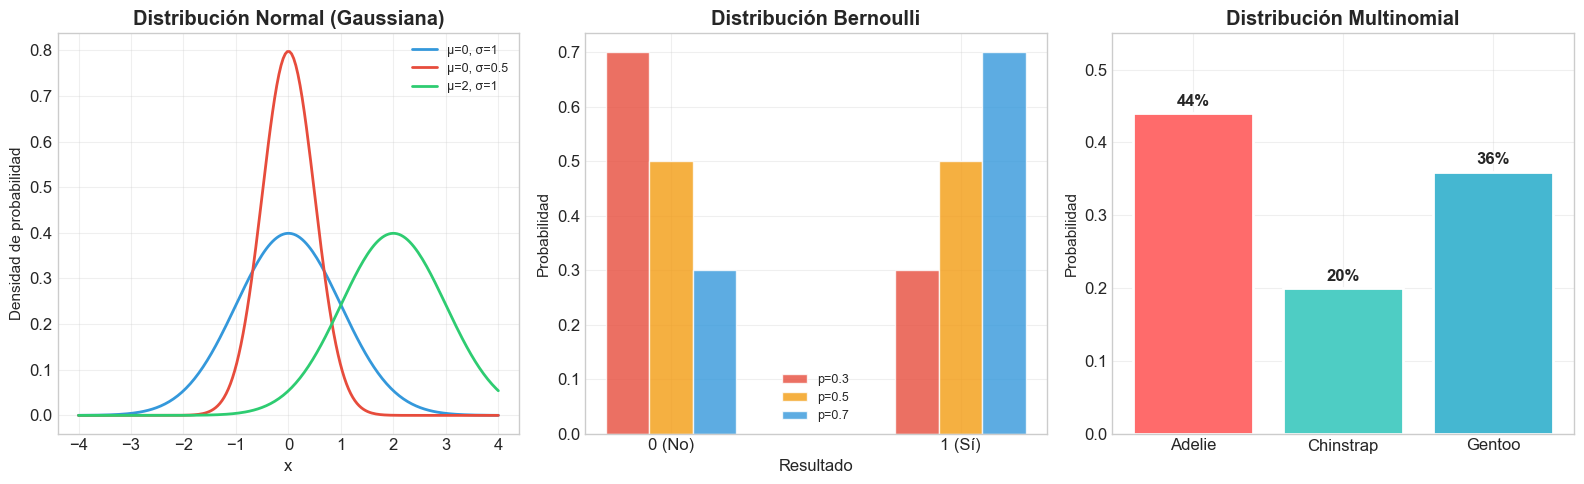

En ML:
  Normal → Errores del modelo, features continuas
  Bernoulli → Clasificación binaria (spam/no spam)
  Multinomial → Clasificación multiclase (especies de pingüinos)


In [14]:
# VISUALIZACION: Distribuciones de probabilidad

from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Distribucion Normal ---
ax = axes[0]
x_norm = np.linspace(-4, 4, 200)
params = [(0, 1, '#3498db', '\u03bc=0, \u03c3=1'),
          (0, 0.5, '#e74c3c', '\u03bc=0, \u03c3=0.5'),
          (2, 1, '#2ecc71', '\u03bc=2, \u03c3=1')]

for mu, sigma, color, label in params:
    y_norm = stats.norm.pdf(x_norm, mu, sigma)
    ax.plot(x_norm, y_norm, color=color, linewidth=2, label=label)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Densidad de probabilidad', fontsize=11)
ax.set_title('Distribuci\u00f3n Normal (Gaussiana)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Distribucion Bernoulli ---
ax = axes[1]
probs = [0.3, 0.5, 0.7]
colores_b = ['#e74c3c', '#f39c12', '#3498db']
ancho = 0.15

for i, (p, color) in enumerate(zip(probs, colores_b)):
    offset = (i - 1) * ancho
    ax.bar([0 + offset, 1 + offset], [1-p, p], width=ancho, color=color,
           edgecolor='white', label=f'p={p}', alpha=0.8)

ax.set_xlabel('Resultado', fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Distribuci\u00f3n Bernoulli', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 (No)', '1 (S\u00ed)'])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Distribucion Multinomial (simulada como barras) ---
ax = axes[2]
categorias = ['Adelie', 'Chinstrap', 'Gentoo']
probabilidades = [0.44, 0.20, 0.36]
colores_m = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax.bar(categorias, probabilidades, color=colores_m, edgecolor='white', linewidth=2)
for bar, prob in zip(bars, probabilidades):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{prob:.0%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Distribuci\u00f3n Multinomial', fontweight='bold')
ax.set_ylim(0, 0.55)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("En ML:")
print("  Normal \u2192 Errores del modelo, features continuas")
print("  Bernoulli \u2192 Clasificaci\u00f3n binaria (spam/no spam)")
print("  Multinomial \u2192 Clasificaci\u00f3n multiclase (especies de ping\u00fcinos)")

### 3.2 Esperanza, Varianza y Covarianza

| Concepto | Qué mide | Fórmula | Uso en ML |
|----------|----------|---------|----------|
| **Esperanza** (E[X]) | El valor promedio esperado | μ = (1/n) Σxᵢ | Centrar datos |
| **Varianza** (Var[X]) | Qué tan dispersos están los datos | σ² = (1/n) Σ(xᵢ - μ)² | Escalar features, detectar outliers |
| **Covarianza** (Cov[X,Y]) | Cómo varían dos variables juntas | (1/n) Σ(xᵢ - μₓ)(yᵢ - μₙ) | Correlación entre features, PCA |

In [15]:
# ============================================================
# ESPERANZA, VARIANZA Y COVARIANZA CON NUMPY
# ============================================================

np.random.seed(42)

# Ejemplo: alturas de 100 personas (en cm)
alturas = np.random.normal(170, 10, 100)  # media=170cm, std=10cm

print("ESTAD\u00cdSTICAS B\u00c1SICAS")
print("=" * 50)
print(f"Datos: alturas de {len(alturas)} personas")
print(f"\nEsperanza (media):          {np.mean(alturas):.2f} cm")
print(f"Varianza:                    {np.var(alturas):.2f} cm\u00b2")
print(f"Desviaci\u00f3n est\u00e1ndar:         {np.std(alturas):.2f} cm")

# Covarianza entre altura y peso
pesos = alturas * 0.6 + np.random.normal(0, 5, 100)  # Correlacion positiva

cov_matrix = np.cov(alturas, pesos)
correlacion = np.corrcoef(alturas, pesos)[0, 1]

print(f"\nCovarianza (altura, peso):   {cov_matrix[0,1]:.2f}")
print(f"Correlaci\u00f3n (altura, peso):   {correlacion:.2f}")
print(f"\nInterpretaci\u00f3n:")
print(f"  Correlaci\u00f3n de {correlacion:.2f} = relaci\u00f3n lineal {'fuerte' if abs(correlacion) > 0.7 else 'moderada'}")
print(f"  Personas m\u00e1s altas tienden a pesar m\u00e1s (correlaci\u00f3n positiva)")
print(cov_matrix)

ESTADÍSTICAS BÁSICAS
Datos: alturas de 100 personas

Esperanza (media):          168.96 cm
Varianza:                    81.65 cm²
Desviación estándar:         9.04 cm

Covarianza (altura, peso):   43.58
Correlación (altura, peso):   0.71

Interpretación:
  Correlación de 0.71 = relación lineal fuerte
  Personas más altas tienden a pesar más (correlación positiva)
[[82.47698936 43.57848398]
 [43.57848398 45.33957703]]


### 3.3 Teorema de Bayes

El Teorema de Bayes nos permite **actualizar nuestras creencias** cuando obtenemos nueva evidencia. Es fundamental para el clasificador Naive Bayes (Semana 9).

```
TEOREMA DE BAYES:

                    P(B|A) * P(A)
   P(A|B)  =  ─────────────────
                      P(B)

   Donde:
   P(A|B) = Probabilidad de A dado que ocurrió B  (posterior)
   P(B|A) = Probabilidad de B dado que ocurrió A  (likelihood)
   P(A)   = Probabilidad de A antes de ver B      (prior)
   P(B)   = Probabilidad total de B               (evidencia)
```

### Ejemplo: Diagnóstico médico

Una prueba detecta una enfermedad rara (1% de la población la tiene).
- Si tienes la enfermedad, la prueba da positivo el 95% de las veces
- Si NO tienes la enfermedad, la prueba da positivo el 5% de las veces (falso positivo)

**Pregunta:** Si la prueba sale positiva, ¿qué probabilidad hay de que realmente tengas la enfermedad?

In [16]:
# ============================================================
# TEOREMA DE BAYES - EJEMPLO MEDICO
# ============================================================

# Datos del problema
P_enfermedad = 0.01       # 1% tiene la enfermedad (prior)
P_no_enfermedad = 0.99    # 99% no tiene
P_positivo_si_enfermo = 0.95    # Sensibilidad (true positive rate)
P_positivo_si_sano = 0.05       # False positive rate

# Paso 1: P(positivo) = P(+|enfermo)*P(enfermo) + P(+|sano)*P(sano)
P_positivo = (P_positivo_si_enfermo * P_enfermedad) + (P_positivo_si_sano * P_no_enfermedad)

# Paso 2: Bayes - P(enfermo|positivo)
P_enfermo_dado_positivo = (P_positivo_si_enfermo * P_enfermedad) / P_positivo

print("TEOREMA DE BAYES - Diagn\u00f3stico M\u00e9dico")
print("=" * 60)
print(f"\nDatos:")
print(f"  P(enfermedad) = {P_enfermedad:.0%}")
print(f"  P(+ | enfermo) = {P_positivo_si_enfermo:.0%}  (sensibilidad)")
print(f"  P(+ | sano) = {P_positivo_si_sano:.0%}  (falso positivo)")
print(f"\nC\u00e1lculo:")
print(f"  P(+) = {P_positivo_si_enfermo}*{P_enfermedad} + {P_positivo_si_sano}*{P_no_enfermedad} = {P_positivo:.4f}")
print(f"\n  P(enfermo | +) = ({P_positivo_si_enfermo} * {P_enfermedad}) / {P_positivo:.4f}")
print(f"                  = {P_enfermo_dado_positivo:.4f}")
print(f"\nRESULTADO: Si la prueba es positiva, solo hay un {P_enfermo_dado_positivo:.1%}")
print(f"de probabilidad de estar enfermo.")
print(f"\nEsto es CONTRAINTUITIVO. Aunque la prueba es 95% precisa,")
print(f"la enfermedad es tan rara que la mayor\u00eda de positivos son falsos positivos.")

TEOREMA DE BAYES - Diagnóstico Médico

Datos:
  P(enfermedad) = 1%
  P(+ | enfermo) = 95%  (sensibilidad)
  P(+ | sano) = 5%  (falso positivo)

Cálculo:
  P(+) = 0.95*0.01 + 0.05*0.99 = 0.0590

  P(enfermo | +) = (0.95 * 0.01) / 0.0590
                  = 0.1610

RESULTADO: Si la prueba es positiva, solo hay un 16.1%
de probabilidad de estar enfermo.

Esto es CONTRAINTUITIVO. Aunque la prueba es 95% precisa,
la enfermedad es tan rara que la mayoría de positivos son falsos positivos.


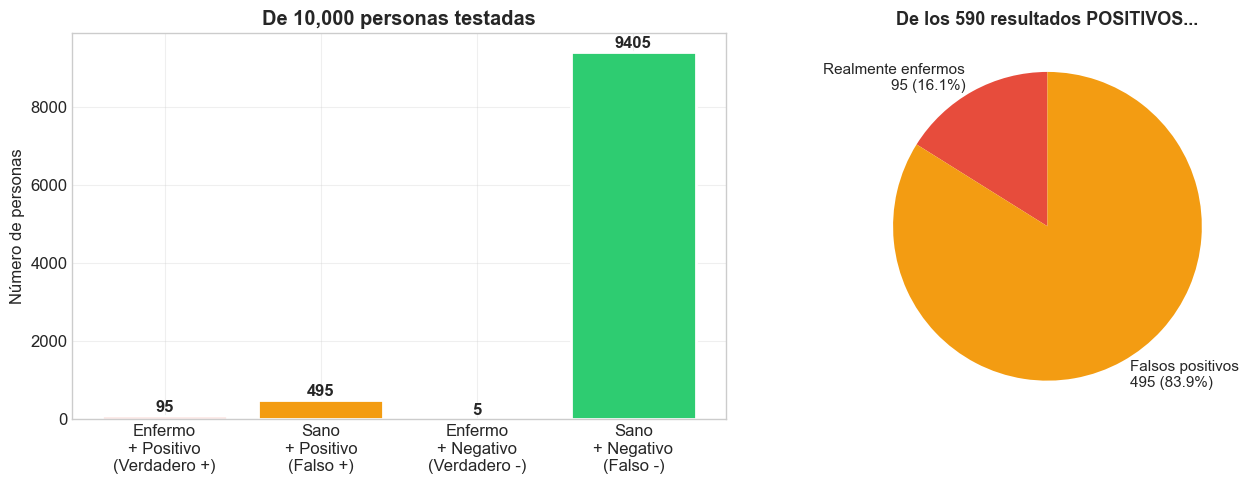


De 590 pruebas positivas, solo 95 son realmente enfermos.
Por eso Bayes es tan importante: el CONTEXTO (prior) importa mucho.


In [22]:
# VISUALIZACION: Teorema de Bayes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: De 10,000 personas ---
ax = axes[0]
n_personas = 10000
enfermos = int(n_personas * P_enfermedad)  # 100
sanos = n_personas - enfermos               # 9900

enfermos_positivos = int(enfermos * P_positivo_si_enfermo)  # 95
enfermos_negativos = enfermos - enfermos_positivos           # 5
sanos_positivos = int(sanos * P_positivo_si_sano)            # 495
sanos_negativos = sanos - sanos_positivos                     # 9405

categorias = ['Enfermo\n+ Positivo\n(Verdadero +)', 'Sano\n+ Positivo\n(Falso +)',
              'Enfermo\n+ Negativo\n(Verdadero -)', 'Sano\n+ Negativo\n(Falso -)']
valores = [enfermos_positivos, sanos_positivos, enfermos_negativos, sanos_negativos]
colores_bayes = ['#e74c3c', '#f39c12', '#95a5a6', '#2ecc71']

bars = ax.bar(categorias, valores, color=colores_bayes, edgecolor='white', linewidth=2)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(val), ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('N\u00famero de personas', fontsize=12)
ax.set_title(f'De {n_personas:,} personas testadas', fontweight='bold')
ax.grid(True, alpha=0.3)

# --- Grafica 2: Proporcion de positivos ---
ax = axes[1]
total_positivos = enfermos_positivos + sanos_positivos
sizes = [enfermos_positivos, sanos_positivos]
labels = [f'Realmente enfermos\n{enfermos_positivos} ({enfermos_positivos/total_positivos:.1%})',
          f'Falsos positivos\n{sanos_positivos} ({sanos_positivos/total_positivos:.1%})']
colores_pie = ['#e74c3c', '#f39c12']

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colores_pie,
                                   autopct='', startangle=90,
                                   textprops={'fontsize': 11})
ax.set_title(f'De los {total_positivos} resultados POSITIVOS...', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('bayes_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDe {total_positivos} pruebas positivas, solo {enfermos_positivos} son realmente enfermos.")
print(f"Por eso Bayes es tan importante: el CONTEXTO (prior) importa mucho.")

### 3.4 Maximum Likelihood Estimation (MLE)

**MLE** es el método que usan muchos algoritmos de ML para encontrar los mejores parámetros. La idea es:

> "Encuentra los parámetros del modelo que hacen que los datos observados sean **lo más probables posible**."

```
Ejemplo: Tienes estos datos de alturas: [165, 170, 168, 172, 175]

Pregunta: Si asumimos que las alturas siguen una distribución Normal,
          ¿qué media (μ) y desviación estándar (σ) hacen que estos
          datos sean más probables?

Respuesta (MLE):
  μ_MLE = promedio de los datos = 170
  σ_MLE = desviación estándar de los datos = 3.39
```

En la práctica, maximizar la likelihood es equivalente a **minimizar** el negative log-likelihood, que es lo que hacen las funciones de costo en ML.

| Algoritmo | Función de costo | Conexión con MLE |
|-----------|-----------------|------------------|
| Regresión lineal | MSE | MLE asumiendo errores normales |
| Regresión logística | Log-Loss | MLE de Bernoulli |
| Naive Bayes | N/A (directo) | Calcula probabilidades directamente |

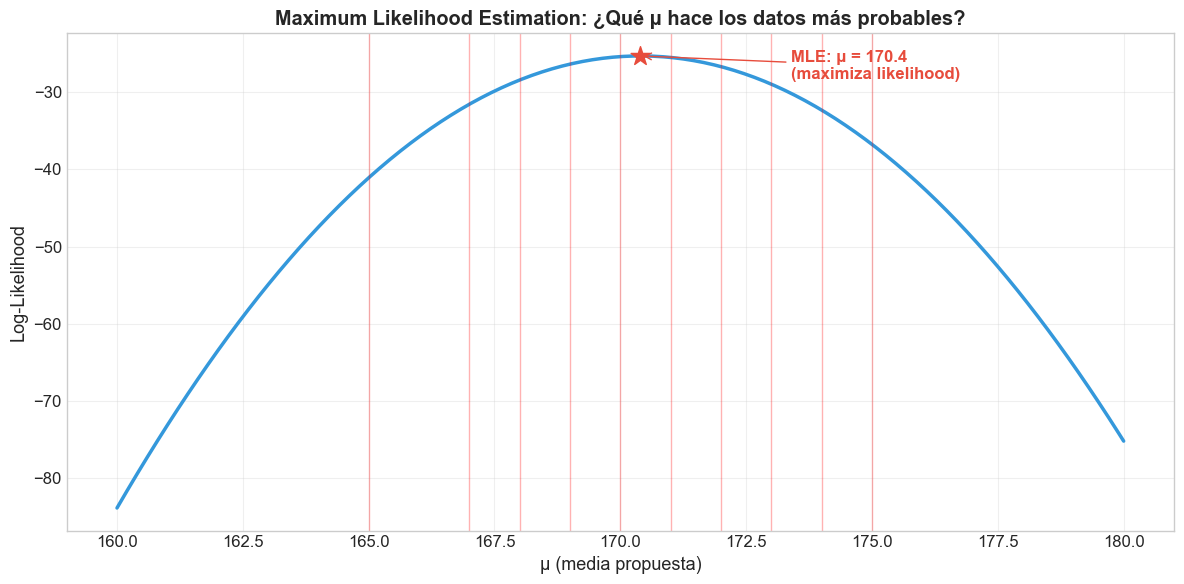

Datos: [165 170 168 172 175 169 171 173 167 174]
MLE de μ = 170.4 (es simplemente el promedio de los datos)
MLE de σ = 3.04

Cuando entrenas modelo.fit(X, y), internamente estás haciendo MLE.


In [24]:
# VISUALIZACION: MLE para encontrar la media de una Normal

np.random.seed(42)
datos_alturas = np.array([165, 170, 168, 172, 175, 169, 171, 173, 167, 174])

fig, ax = plt.subplots(figsize=(12, 6))

# Probar diferentes medias y calcular la log-likelihood
medias_prueba = np.linspace(160, 180, 200)
sigma = np.std(datos_alturas)

log_likelihoods = []
for mu in medias_prueba:
    ll = np.sum(stats.norm.logpdf(datos_alturas, mu, sigma))
    log_likelihoods.append(ll)

log_likelihoods = np.array(log_likelihoods)

ax.plot(medias_prueba, log_likelihoods, color='#3498db', linewidth=2.5)

# Marcar el MLE (la media de los datos)
mu_mle = np.mean(datos_alturas)
ll_mle = np.sum(stats.norm.logpdf(datos_alturas, mu_mle, sigma))
ax.scatter([mu_mle], [ll_mle], color='#e74c3c', s=200, zorder=5, marker='*')
ax.annotate(f'MLE: \u03bc = {mu_mle:.1f}\n(maximiza likelihood)',
            xy=(mu_mle, ll_mle), xytext=(mu_mle + 3, ll_mle - 3),
            fontsize=12, color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Marcar los datos
for d in datos_alturas:
    ax.axvline(x=d, color='red', linewidth=1, alpha=0.3)

ax.set_xlabel('\u03bc (media propuesta)', fontsize=13)
ax.set_ylabel('Log-Likelihood', fontsize=13)
ax.set_title('Maximum Likelihood Estimation: \u00bfQu\u00e9 \u03bc hace los datos m\u00e1s probables?',
             fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mle_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Datos: {datos_alturas}")
print(f"MLE de \u03bc = {mu_mle:.1f} (es simplemente el promedio de los datos)")
print(f"MLE de \u03c3 = {sigma:.2f}")
print(f"\nCuando entrenas modelo.fit(X, y), internamente est\u00e1s haciendo MLE.")

---

## 4. Conectando Todo: Las Matemáticas dentro de ML

Ahora veamos cómo se conecta todo con un ejemplo práctico de **regresión lineal**.

```
REGRESIÓN LINEAL = Álgebra Lineal + Cálculo + Probabilidad

1. MODELO (Álgebra Lineal):
   ŷ = X · w + b
   (multiplicación de matrices)

2. FUNCIÓN DE COSTO (Probabilidad/Estadística):
   MSE = (1/n) Σ(yᵢ - ŷᵢ)²
   (equivalente a MLE asumiendo errores normales)

3. OPTIMIZACIÓN (Cálculo):
   w = w - α * ∇MSE
   (gradiente descendente para minimizar el costo)
```

In [19]:
# ============================================================
# EJEMPLO COMPLETO: Regresion Lineal con Gradiente Descendente
# ============================================================

np.random.seed(42)

# Generar datos sinteticos: y = 3x + 7 + ruido
n = 50
X_datos = np.random.uniform(0, 10, n)
y_datos = 3 * X_datos + 7 + np.random.normal(0, 2, n)

# Parametros iniciales
w = 0.0   # pendiente
b = 0.0   # intercepto
lr = 0.01
epochs = 100

hist_w, hist_b, hist_loss = [w], [b], []

print("REGRESI\u00d3N LINEAL CON GRADIENTE DESCENDENTE")
print("=" * 60)
print(f"Datos: y = 3x + 7 + ruido  (queremos descubrir w=3, b=7)")
print(f"Inicio: w={w}, b={b}")
print(f"Learning rate: {lr}")
print(f"\n{'Epoch':>6} {'w':>8} {'b':>8} {'MSE':>10}")
print("-" * 40)

for epoch in range(epochs):
    # Forward pass: prediccion
    y_pred = w * X_datos + b
    
    # Calcular error (MSE)
    error = y_datos - y_pred
    mse = np.mean(error**2)
    hist_loss.append(mse)
    
    # Calcular gradientes
    dw = -2 * np.mean(error * X_datos)  # dMSE/dw
    db = -2 * np.mean(error)            # dMSE/db
    
    # Actualizar parametros
    w = w - lr * dw
    b = b - lr * db
    hist_w.append(w)
    hist_b.append(b)
    
    if epoch < 5 or epoch % 20 == 19:
        print(f"{epoch:>6} {w:>8.4f} {b:>8.4f} {mse:>10.4f}")

print(f"\nResultado:  w = {w:.4f} (real: 3.0),  b = {b:.4f} (real: 7.0)")

REGRESIÓN LINEAL CON GRADIENTE DESCENDENTE
Datos: y = 3x + 7 + ruido  (queremos descubrir w=3, b=7)
Inicio: w=0.0, b=0.0
Learning rate: 0.01

 Epoch        w        b        MSE
----------------------------------------
     0   2.3003   0.4074   489.7331
     1   3.2731   0.6016   101.0277
     2   3.6826   0.7051    30.8951
     3   3.8531   0.7700    18.1487
     4   3.9221   0.8184    15.7407
    19   3.8935   1.3489    13.3636
    39   3.7924   1.9786    11.3104
    59   3.7022   2.5404     9.6757
    79   3.6218   3.0417     8.3743
    99   3.5500   3.4890     7.3382

Resultado:  w = 3.5500 (real: 3.0),  b = 3.4890 (real: 7.0)


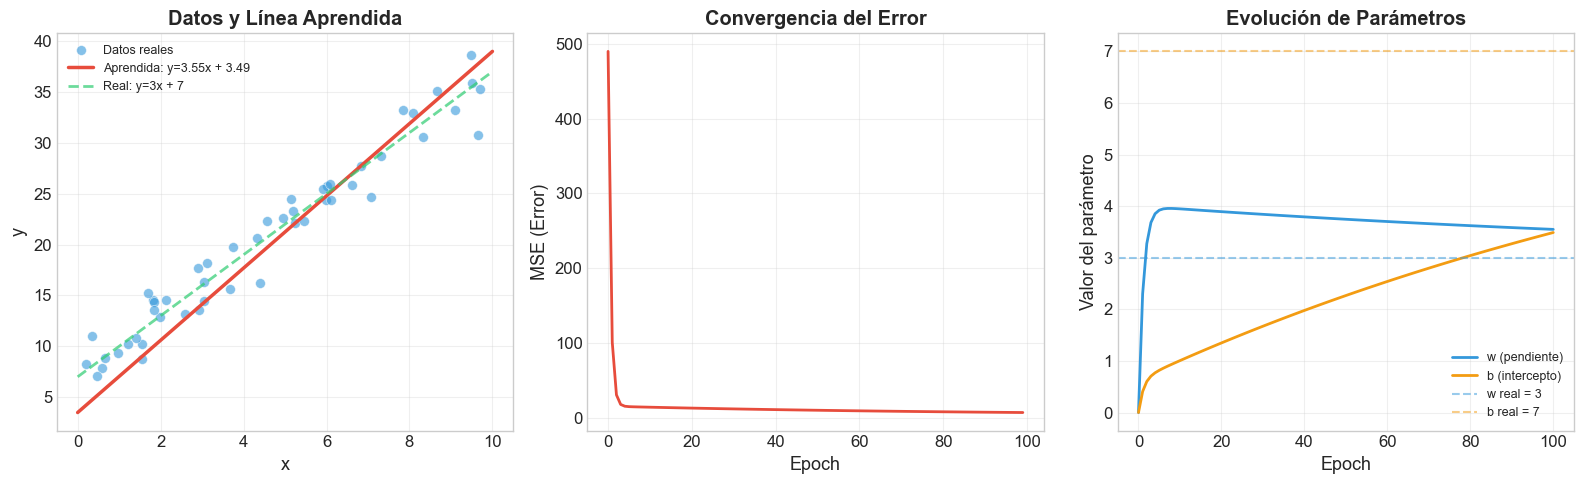

Esto es EXACTAMENTE lo que hace scikit-learn por dentro cuando llamas modelo.fit()
Solo que optimizado y con muchas mejoras adicionales.


In [20]:
# VISUALIZACION: Regresion lineal aprendida con GD

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Grafica 1: Datos y linea aprendida ---
ax = axes[0]
ax.scatter(X_datos, y_datos, alpha=0.6, s=50, c='#3498db', edgecolors='white',
           linewidth=0.5, label='Datos reales')
x_line = np.linspace(0, 10, 100)
ax.plot(x_line, w * x_line + b, color='#e74c3c', linewidth=2.5,
        label=f'Aprendida: y={w:.2f}x + {b:.2f}')
ax.plot(x_line, 3 * x_line + 7, color='#2ecc71', linewidth=2, linestyle='--',
        label='Real: y=3x + 7', alpha=0.7)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Datos y L\u00ednea Aprendida', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Grafica 2: Convergencia del error ---
ax = axes[1]
ax.plot(range(len(hist_loss)), hist_loss, color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE (Error)', fontsize=13)
ax.set_title('Convergencia del Error', fontweight='bold')
ax.grid(True, alpha=0.3)

# --- Grafica 3: Evolucion de w y b ---
ax = axes[2]
ax.plot(range(len(hist_w)), hist_w, color='#3498db', linewidth=2, label='w (pendiente)')
ax.plot(range(len(hist_b)), hist_b, color='#f39c12', linewidth=2, label='b (intercepto)')
ax.axhline(y=3, color='#3498db', linestyle='--', alpha=0.5, label='w real = 3')
ax.axhline(y=7, color='#f39c12', linestyle='--', alpha=0.5, label='b real = 7')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Valor del par\u00e1metro', fontsize=13)
ax.set_title('Evoluci\u00f3n de Par\u00e1metros', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regresion_gd_completo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Esto es EXACTAMENTE lo que hace scikit-learn por dentro cuando llamas modelo.fit()")
print("Solo que optimizado y con muchas mejoras adicionales.")

---

## 5. Resumen de la Semana 2

### Lo que aprendimos hoy

| Tema | Concepto Clave | Uso en ML |
|------|---------------|----------|
| **Vectores** | Representan muestras de datos | Cada fila del dataset es un vector |
| **Matrices** | Operaciones sobre todo el dataset | X @ w = predicciones |
| **Producto punto** | Mide similitud, calcula predicciones | Regresión, redes neuronales |
| **Eigenvectores** | Direcciones principales de variación | PCA (Semana 12) |
| **Derivadas** | Dirección de cambio de la función | Gradiente descendente |
| **Gradiente** | Vector de derivadas parciales | Optimizar parámetros |
| **Learning rate** | Controla tamaño de los pasos | Hiperparámetro crítico |
| **Distribuciones** | Modelan la incertidumbre | Normal, Bernoulli, Multinomial |
| **Bayes** | Actualizar creencias con evidencia | Naive Bayes (Semana 9) |
| **MLE** | Encontrar los mejores parámetros | Casi todo en ML |

### Fórmulas esenciales

```python
# Algebra lineal
np.dot(v1, v2)           # Producto punto
np.linalg.norm(v)        # Norma del vector
A @ B                    # Multiplicacion de matrices
np.linalg.inv(A)         # Inversa
np.linalg.eig(A)         # Eigenvalores y eigenvectores

# Estadistica
np.mean(datos)           # Media (esperanza)
np.var(datos)            # Varianza
np.cov(x, y)            # Covarianza
np.corrcoef(x, y)       # Correlacion

# Gradiente descendente
w = w - lr * gradiente   # Actualizacion de parametros
```

---

## 6. Recursos Adicionales

### Para profundizar esta semana:

**Videos:**
- [Essence of Linear Algebra - 3Blue1Brown](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) - La mejor serie visual de álgebra lineal
- [Gradient Descent - StatQuest](https://www.youtube.com/watch?v=sDv4f4s2SB8)
- [Bayes theorem - 3Blue1Brown](https://www.youtube.com/watch?v=HZGCoVF3YvM)

**Lecturas:**
- Capítulos 1-2 de "Pattern Recognition and Machine Learning" de Bishop
- [Mathematics for Machine Learning (libro gratuito)](https://mml-book.github.io/)

**Práctica:**
- [NumPy Tutorial Oficial](https://numpy.org/doc/stable/user/quickstart.html)
- Experimenta cambiando el learning rate y punto inicial en los ejemplos de arriba

---

## Prepárate para el Reto de la Semana 2

En el reto implementarás **gradiente descendente desde cero** para:
1. Encontrar el mínimo de funciones en 1D y 2D
2. Experimentar con diferentes learning rates
3. Graficar la trayectoria de convergencia
4. Descubrir por ti mismo cuándo funciona y cuándo falla

---

_Semana 2 - Matemáticas para Machine Learning | DataQuest 2026_